Note: you may need to restart the kernel to use updated packages.
Python implementation: CPython
Python version       : 3.10.6
IPython version      : 8.7.0

watermark : 2.3.1
numpy     : 1.23.1
pandas    : 1.4.3
matplotlib: 3.5.3
torch     : 1.12.0+cu116



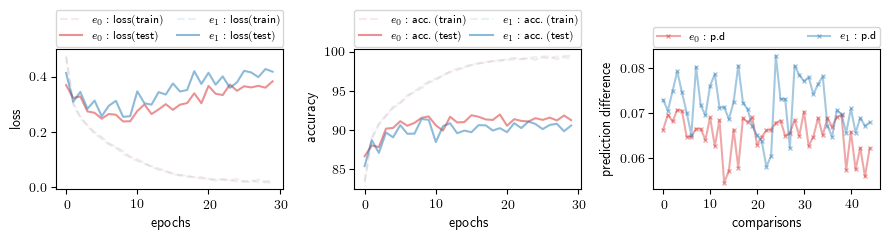

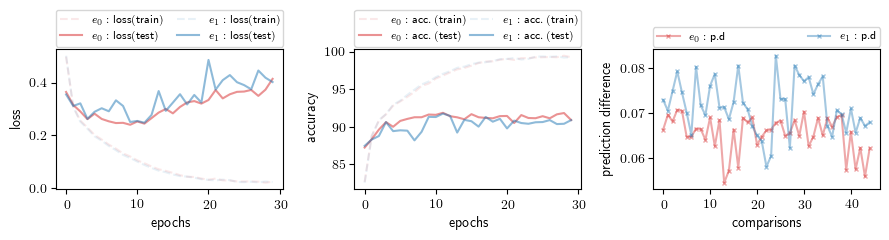

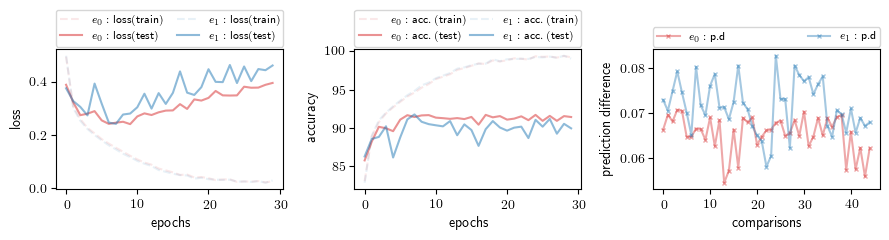

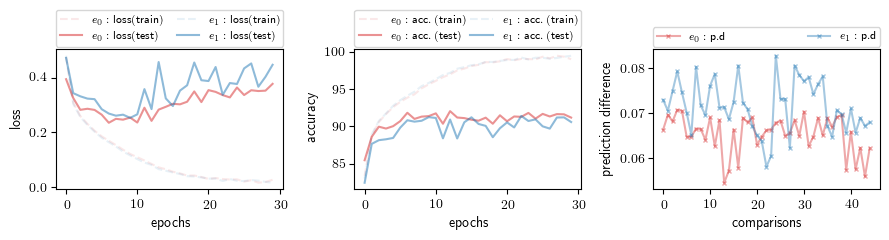

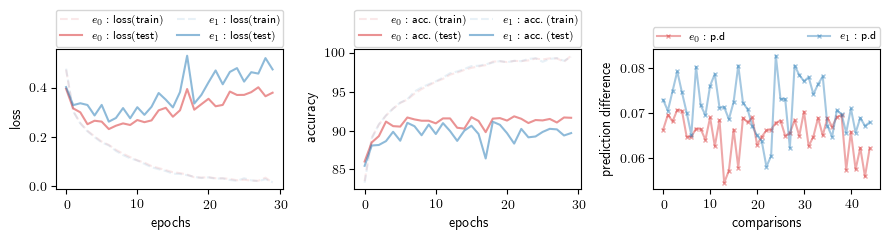

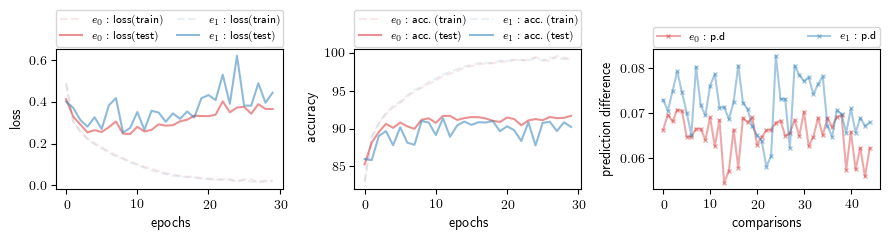

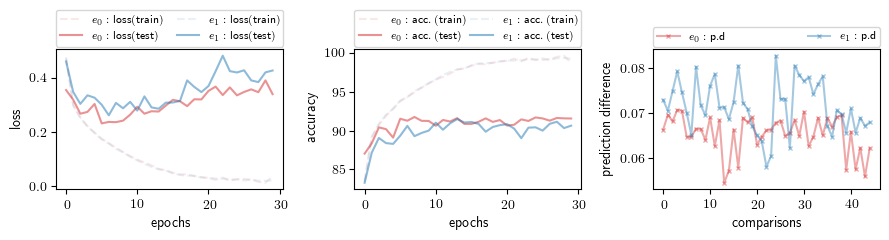

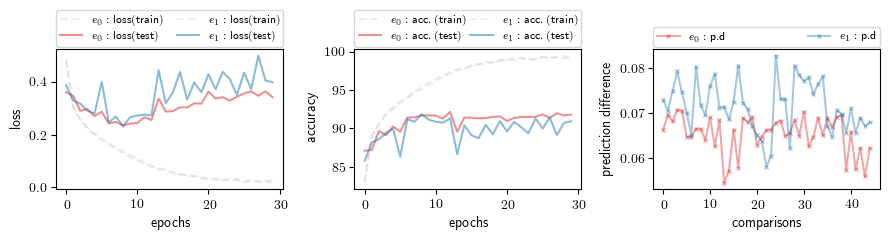

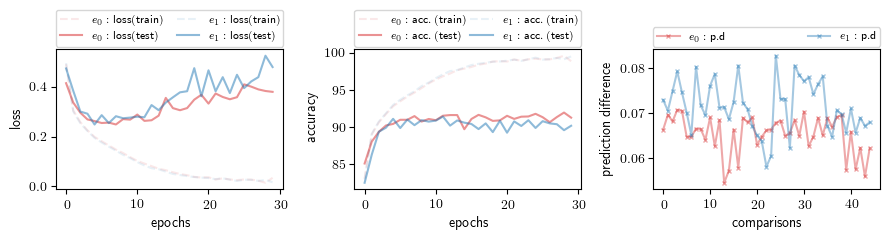

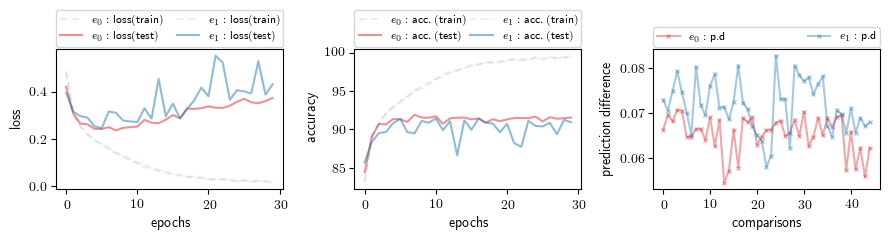


Done!


In [1]:
%pip install watermark numpy pandas matplotlib torch torchvision torchaudio | grep -v 'already satisfied'
%load_ext watermark
%watermark -v -p watermark,numpy,pandas,matplotlib,torch

#
import math,random,os,sys,copy,time,glob,itertools,shutil,re,json
from scipy.stats import wilcoxon

#
import numpy as np

#
import torch, gc
torch.cuda.empty_cache()
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import torch.nn as nn
import torch.nn.functional as tf
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Lambda

import pandas as pd

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
    
from mpl_toolkits import mplot3d
from mpl_toolkits import mplot3d
from mpl_toolkits import mplot3d
import matplotlib.animation as animation
from matplotlib import gridspec
from IPython.display import clear_output
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch
from matplotlib.text import Annotation
from mpl_toolkits.mplot3d.proj3d import proj_transform

from pathlib import Path
sys.path[0] = str(Path(sys.path[0]).parent)

from demofcns import *

cmd_exists = lambda x: shutil.which(x) is not None
if cmd_exists('latex'):
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "sans-serif", # serif
        "font.sans-serif": "Helvetica", # Times, Palatino, Computer Modern Roman
    })
else:
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
    })


'''
Compare the runidx of: [obj1, obj2,...,objn], 
where all obji in list has the same dataset, number of runs and epochs
'''

# --- Inputs ---
runs_idx = 3
data_name = "fmnist"
batch_size = 128
runs = 10
epochs = 30
pstr = str(batch_size)+"_"+data_name+"_"+str(runs)+"_"+str(epochs)

class Obj(object):
  pass

obj1 = Obj()
obj1.mdl_name_dir = "nndemo5_fmnist_resnet6"
obj1.storedir = "../expstore"
obj1.pathstr = obj1.mdl_name_dir+pstr
obj1.scfgspath = f"{obj1.storedir}/{obj1.mdl_name_dir}/stores/exp_cfg/cfgs_{obj1.pathstr}.json"
obj1.color = "tab:red"

obj2 = Obj()
obj2.mdl_name_dir = "nndemo5f_fmnist_resnet6"
obj2.storedir = "../expstore"
obj2.pathstr = obj2.mdl_name_dir+pstr
obj2.scfgspath = f"{obj2.storedir}/{obj2.mdl_name_dir}/stores/exp_cfg/cfgs_{obj2.pathstr}.json"
obj2.color = "tab:blue"

# obj3.color = "tab:orange"
# obj4.color = "tab:green"


objs = [obj1, obj2]


# --- Function ---

def addhandle(h, hi):
  '''
  Add axes handle, 'hi' to a concatenated group 'h'
  '''
  if h is None:
    h = hi
  else:
    h += hi
    return h  
  
  
for rid in range(runs):
  runs_idx = rid+1
  
  # --- Line plot for each runs_idx ---
  figsz = (3*3, 2*1.25)
  fig1 = plt.figure(figsize=figsz,tight_layout=True)
  gridpanel  = gridspec.GridSpec(1,3,)
  # loss
  ax1 = plt.subplot(gridpanel[0])
  ax1handles = None
  # acc
  ax2 = plt.subplot(gridpanel[1])
  ax2handles = None
  # p.d
  ax3 = plt.subplot(gridpanel[2])
  ax3handles = None

  # --- Get and Plot ---
  for id,obj in enumerate(objs):
    with open(obj.scfgspath, 'r') as cfglist:
      scfgs = json.load(cfglist)
    # train_losses_ list_per_run train_accs_list_per_run
    path_train_loss = f"{obj.storedir}/{obj.mdl_name_dir}/stores/acc/trainloss_{obj.pathstr}"
    path_train_acc= f"{obj.storedir}/{obj.mdl_name_dir}/stores/acc/trainacc_{obj.pathstr}"
    path_dev_loss = f"{obj.storedir}/{obj.mdl_name_dir}/stores/acc/devloss_{obj.pathstr}"
    path_dev_acc= f"{obj.storedir}/{obj.mdl_name_dir}/stores/acc/devacc_{obj.pathstr}"

    dfl = pd.read_csv(path_train_loss+".csv")
    dfa = pd.read_csv(path_train_acc+".csv")

    # access the data
    train_loss_per_run = dfl.iloc[0:,runs_idx]
    train_acc_per_run = dfa.iloc[0:,runs_idx]

    dfl = pd.read_csv(path_dev_loss+".csv")
    dfa = pd.read_csv(path_dev_acc+".csv")

    # access the data
    dev_loss_per_run = dfl.iloc[0:,runs_idx]
    dev_acc_per_run = dfa.iloc[0:,runs_idx]

    #inputs:
    epochs_t = np.arange(scfgs['epochs'])
    trainlosses = np.array(train_loss_per_run)
    accs = []


    # Plot training and validation curves
    # fig, ax1 = plt.subplots(figsize=figsz)
    color = obj.color
    
    # l
    obj.l1l = ax1.plot(epochs_t, train_loss_per_run.values, linestyle='dashed', c=color,alpha=0.1, label=rf"$e_{id}:\mathrm{{\mathsf{{loss\/(train)}}}}$")
    obj.l2l = ax1.plot(epochs_t, dev_loss_per_run.values, c=color,
    alpha=0.5, label=rf"$e_{id}:\mathrm{{\mathsf{{loss\/(test)}}}}$")
    # marker='.', markersize=3, markevery=10
    ax1.set_xlabel(r"$\mathrm{\mathsf{epochs}}$")
    ax1.set_ylabel(r'$\mathrm{\mathsf{loss}}$')
    # ax1.tick_params(axis='y', labelcolor=color)
    # ax1.set_ylim(-0.01,3)
    ax1handles = addhandle(ax1handles,obj.l1l)
    ax2handles = addhandle(ax1handles,obj.l2l)
    
    # a
    obj.l1a = ax2.plot(epochs_t, train_acc_per_run.values, linestyle='dashed', c=color,alpha=0.1, label=rf"$e_{id}:\mathrm{{\mathsf{{acc.~(train)}}}}$")
    obj.l2a = ax2.plot(epochs_t, dev_acc_per_run.values, c=color,
    alpha=0.5, label=rf"$e_{id}:\mathrm{{\mathsf{{acc.~(test)}}}}$")
    ax2.set_xlabel(r"$\mathrm{\mathsf{epochs}}$")
    ax2.set_ylabel(r"$\mathrm{\mathsf{accuracy}}$")
    # ax2.tick_params(axis='y', labelcolor=color)
    # ax2.set_ylim(-0.01,3)
    ax2handles = addhandle(ax2handles,obj.l2a)
    ax2handles = addhandle(ax2handles,obj.l2a)
    
    # p.d
    if scfgs["runs"] > 1:
      path_preds= f"{obj.storedir}/{obj.mdl_name_dir}/stores/pdiff/pdiff_{obj.pathstr}"
      dfp = pd.read_csv(path_preds+".csv")
      dev_preds_per_run = dfp.iloc[0:,1]
      obj.l3a = ax3.plot(dev_preds_per_run.values, c=color, 
      alpha=0.4, marker='x', markersize=3,label=rf"$e_{id}:\mathrm{{\mathsf{{p.d}}}}$")
      ax3.set_xlabel(r"$\mathrm{\mathsf{comparisons}}$")
      ax3.set_ylabel(rf"$\mathrm{{\mathsf{{prediction~difference}}}}$")
      # ax3.set_ylim(-0.01,3)
      ax3handles = addhandle(ax3handles,obj.l3a)
    

  # --- Legend ---
  ax1.legend(handles=ax1handles, fontsize=8, 
            bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
            ncol=2, mode="expand", borderaxespad=0.)
  ax2.legend(handles=ax2handles, fontsize=8, 
            bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
            ncol=2, mode="expand", borderaxespad=0.)
  ax3.legend(handles=ax3handles, fontsize=8, 
            bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
            ncol=2, mode="expand", borderaxespad=0.)

  # ax1.axhline(y=scfgs['eff_test_accuracy'],c=color,alpha=0.8)
  # marker='.', markersize=3, markevery=10
  plt.show()

  # --- Save ---
  objc = Obj()
  objc.mdl_name_dir = "cmp_demo5"
  objc.storedir = "../expstore"
  os.makedirs(f"{objc.storedir}/{objc.mdl_name_dir}", exist_ok=True)
  fig1.savefig(f"{objc.storedir}/{objc.mdl_name_dir}/train_test_{runs_idx}_curves.png", dpi=300)
  
print('\nDone!')
# --- End ---

